In [1]:
import pandas as pd
import numpy as np

from mpl_toolkits.axes_grid1.inset_locator import inset_axes # inset

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# qqplot
import statsmodels.api as sm
import pylab as py

from scipy.stats import mannwhitneyu,wilcoxon,spearmanr,ttest_ind
from scipy.stats import sem

import json
import anytree

In [2]:
import sys
sys.path.append('/Users/dbao/Downloads/research/rc_scripts/submission/analysis')

from process_helper.df_choice_add_features import df_choice_add_features
from process_helper.df_map_add_features import df_map_add_features
from process_helper.df_undo_start_end import df_undo_start_end
from process_helper.df_subset_undo import df_subset_undo

import plot_helper.format
from plot_helper.text import text
save_mode = ".pdf"
font_size = 9

In [3]:
%load_ext rpy2.ipython

from rpy2.robjects.packages import importr
# import R's "base" package
lme4 = importr('lme4')
mass = importr('MASS')
rcompanion = importr('rcompanion')

/Users/dbao/opt/anaconda3/envs/road/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:14: FutureWarning: pandas.core.index is deprecated and will be removed in a future version. The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


# Load data

In [4]:
home_dir = '/Users/dbao/Library/CloudStorage/GoogleDrive-sherrydbao@gmail.com/My Drive/road_construction_data/data/2022_online/'
data_dir = home_dir + 'R_analysis_data/'
out_dir = home_dir + 'figures/figures_final/'
out_dir2 = home_dir + 'stat_model/final/'

In [5]:
data_choice_level = pd.read_csv(data_dir +  'choice_level/choicelevel_data.csv') # first column is index  
data_choice_level = data_choice_level.rename(columns={'Unnamed: 0':'index_copy'})

pd.options.mode.chained_assignment = None  # Suppress the SettingWithCopyWarning
data_choice_level = df_choice_add_features(data_choice_level)
sc_data_choice_level = data_choice_level[data_choice_level['condition']==1].reset_index(drop=True) 

In [6]:
data_puzzle_level = pd.read_csv(data_dir +  'data_new.csv') # first column is subject
data_puzzle_level = df_map_add_features(data_puzzle_level, data_choice_level)

In [7]:
single_condition_data = data_puzzle_level[data_puzzle_level['condition']==1].copy()
single_condition_data = single_condition_data.reset_index(drop=True)

In [8]:
with open('/Users/dbao/Library/CloudStorage/GoogleDrive-sherrydbao@gmail.com/My Drive/road_construction_data/data/2020_pilot/experiment/map/basic_map_pool/basic_tree_500', 'r') as file:
    tree = json.load(file)

In [19]:
from anytree.importer import DictImporter
importer = DictImporter()
n_states = []
for i in range(len(tree)):
    root = importer.import_(tree[i])
    n_states.append(len(root.leaves))
print(n_states)
# print range of n_states
print(min(n_states))
print(max(n_states))


KeyboardInterrupt: 

# Tree count

# *SUPP: Puzzle MAS distribution

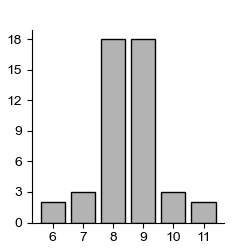

In [ ]:
%matplotlib widget

n_mas = single_condition_data[single_condition_data.subjects==2].groupby(['mas'])['mas'].count() # only undo condition

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(2.5, 2.5)
plt.rcParams.update({'font.size': font_size})
axs.bar(range(6,12), n_mas,
        color = (.7,.7,.7),
        edgecolor = 'k')## puzzle MAS

### histogram of MAS/remaining budget, numFullUndo',)
axs.set_ylabel('Number of maps') 
axs.set_yticks(list(range(0, 20, 3)))
axs.set_xticks(range(6,12))
axs.set_xlabel('Maximum possible score \nof the initial state')
# change size ratio to be 1:1
axs.set_aspect(1/axs.get_data_ratio(), adjustable='box')
#plt.show()
fig.savefig(out_dir + 'count_mas_puzzle'+save_mode, dpi=300, bbox_inches='tight')

# *Total RT

In [ ]:
TT = data_puzzle_level.groupby(['subjects','puzzleID','condition'])['TT'].sum().groupby(['subjects','condition']).mean().groupby(['condition'])
print(TT.mean(), TT.sem())

condition
0    17.305822
1    22.532387
Name: TT, dtype: float64 condition
0    0.588342
1    0.961501
Name: TT, dtype: float64


# Reward RT ratio

In [9]:
final_reward_RT_ratio = data_puzzle_level.groupby(['subjects','puzzleID','condition'])['final_reward_RT_ratio'].sum().groupby(['subjects','condition']).mean().groupby(['condition'])
print(final_reward_RT_ratio.mean(), final_reward_RT_ratio.sem())

condition
0    5.197425
1    4.766731
Name: final_reward_RT_ratio, dtype: float64 condition
0    0.169347
1    0.161883
Name: final_reward_RT_ratio, dtype: float64


# *fig 1c: Number of undo

In [20]:
num_undo = single_condition_data.groupby(['subjects','puzzleID'])['numFullUndo'].sum().groupby('subjects').mean()
print(num_undo.mean(), num_undo.sem())

0.5782608695652174 0.06402884176645277


In [21]:
# get the difference between two conditions for final_sumSeverityErrors
groupby_df = data_puzzle_level.groupby(['subjects','puzzleID','condition'])['final_sumSeverityErrors'].mean().reset_index()
pivot_df = groupby_df.pivot(
    index=['subjects', 'puzzleID'],
    columns='condition',
    values='final_sumSeverityErrors'
).reset_index()

# Calculate the difference between conditions
# Replace 'condition1' and 'condition2' with your actual condition names
diff_df = pivot_df.assign(
    condition_difference=pivot_df[1] - pivot_df[0]
)
spearmanr(diff_df.groupby('subjects')['condition_difference'].mean(), num_undo)

SpearmanrResult(correlation=-0.6469908391760131, pvalue=3.530709603142368e-13)

In [22]:
spearmanr(num_undo, single_condition_data.groupby(['subjects'])['final_sumSeverityErrors'].mean())

SpearmanrResult(correlation=-0.655712683252394, pvalue=1.325309397327539e-13)

In [23]:
unique_values = np.sort(single_condition_data['numFullUndo'].unique())
# Adjust bins to combine values larger than 4 into one bin
# Find the index of the bin that corresponds to the value 4
index_of_4 = np.searchsorted(unique_values, 4, side='right')
# Adjust bins to include only up to the value of 4 and one additional bin for all values > 4
adjusted_bins = np.concatenate((unique_values[:index_of_4 + 1], [unique_values[-1] + 0.5]))

# Recompute histograms with adjusted bins
subject_histograms = single_condition_data.groupby('subjects')['numFullUndo'].apply(
    lambda x: np.histogram(x, bins=adjusted_bins, density=True)[0]
)
subject_histograms_df = pd.DataFrame(subject_histograms.tolist())

# Since bins have been adjusted, recalculate mean and SEM for the new bins
mean_histogram = subject_histograms_df.mean()
sem_histogram = subject_histograms_df.sem()

# Calculate the sum of proportions for columns 1-5 (indices 1, 2, 3, 4, 5) for each subject
# This represents the proportion of puzzles where the subject used at least one undo
sum_proportions = subject_histograms_df.iloc[:, 1:6].sum(axis=1)

# Calculate the mean and standard error of the mean (SEM) of these sums
mean_sum_proportion = sum_proportions.mean()
sem_sum_proportion = sum_proportions.sem()

print(f"Mean proportion of puzzles with at least one undo: {mean_sum_proportion:.3f}")
print(f"SEM of proportion of puzzles with at least one undo: {sem_sum_proportion:.3f}")


# Adjust bin_edges and bin_centers for plotting, if necessary
# Define new bin edges considering the adjustment
adjusted_bin_edges = adjusted_bins
# Calculate new bin centers
adjusted_bin_centers = (adjusted_bin_edges[:-1] + adjusted_bin_edges[1:]) / 2

# (single_condition_data['numFullUndo']>1).sum()/len(single_condition_data)

Mean proportion of puzzles with at least one undo: 0.293
SEM of proportion of puzzles with at least one undo: 0.023


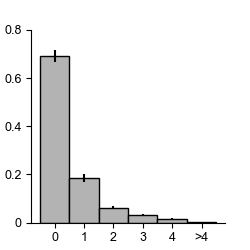

In [25]:
%matplotlib widget

fig, axs = plt.subplots(1, 1)
fig.set_size_inches(2.5, 2.5)
plt.rcParams.update({'font.size': font_size})

plt.bar(range(0,6), mean_histogram, 
        width=(adjusted_bin_edges[1] - adjusted_bin_edges[0]), 
        yerr=sem_histogram, capsize=0, 
        color = (.7,.7,.7), 
        edgecolor = 'k')
# modify xtick labels
axs.set_xticks(range(0,6), ["0", "1", "2", "3", "4", ">4"])
formatter = FuncFormatter(lambda y, _: f'{int(y)}' if y == int(y) else f'{y:.1f}')
axs.yaxis.set_major_formatter(formatter)
axs.set_ylim([0,0.8])
axs.set_xlabel('Number of undos')
axs.set_ylabel('Proportion')
plt.show()
plt.tight_layout()
plt.savefig(out_dir + 'hist_undo' + save_mode, dpi=300, bbox_inches='tight')

# *action gap - RT1

In [8]:
# bin "action_gap" of puzzleID_order_data, which ranges from 2.5 to 6
temp, cutoff_actiongap = pd.cut(data_puzzle_level['action_gap'], 5 , labels = False, retbins=True)
data_puzzle_level["action_gap_bin"] = temp

In [9]:
# correlation between RT1 for each condition
x1 = data_puzzle_level[data_puzzle_level.condition==1].groupby(['puzzleID'])['RT1'].mean()
x2 = data_puzzle_level[data_puzzle_level.condition==0].groupby(['puzzleID'])['RT1'].mean()
spearmanr(x1,x2)

SpearmanrResult(correlation=0.5728646315140302, pvalue=3.174956286948255e-05)

In [13]:
action_gap = data_puzzle_level[data_puzzle_level.condition==1].groupby(['puzzleID'])['action_gap'].mean()
print(spearmanr(x1, action_gap))
print(spearmanr(x2, action_gap))

SpearmanrResult(correlation=-0.4115216215854192, pvalue=0.004492340940559376)
SpearmanrResult(correlation=-0.5910688998280984, pvalue=1.5255591168665379e-05)


In [16]:
data_puzzle_level['cumulative_error'] = data_puzzle_level.mas - data_puzzle_level.numCities
cumulative_error = data_puzzle_level[data_puzzle_level.condition==0].groupby(['puzzleID'])['cumulative_error'].mean()
print(spearmanr(cumulative_error, action_gap))

SpearmanrResult(correlation=0.4388686694219973, pvalue=0.002280250981185541)


# *move RT

In [19]:
def get_RT_cond(cond,RTtype):
    RT = data_puzzle_level[data_puzzle_level['condition']==cond]
    RT_sub = RT.groupby(['subjects'])[RTtype].mean()
    RT_sub_sem = sem(RT_sub)
    return [RT_sub,RT_sub_sem]

RT1_basic = get_RT_cond(0,'RT1')
RT1_undo = get_RT_cond(1,'RT1')

RTlater_basic = get_RT_cond(0,'RTlater')
RTlater_undo = get_RT_cond(1,'RTlater')

In [24]:
# Create a copy explicitly first
test_df = data_choice_level[(data_choice_level.undo==0) & (data_choice_level.RT!=-1)].copy()
test_df.loc[:, 'first_move'] = (test_df['currNumCities'] == 1)
test_df['log_RT'] = np.log(test_df['RT']/1000+1)

# save test_df as csv
test_df.to_csv(data_dir +'moveRT_df.csv', index=False)
